# 13 — AIA ResNet18 Cycle/Regime Diagnostics

**Purpose.** This notebook performs a CPU-only regime diagnostic analysis after the physics-safe ResNet18 multifold and hyperparameter sensitivity studies.

It does **not** train any model.

It uses existing outputs from:

- Notebook 11: ResNet18 physics-safe multifold full-natural baseline.
- Notebook 12: ResNet18 physics-safe multifold hyperparameter sensitivity.
- Notebook 12 add-on: multifold error analysis and research log update.

## Scientific question

The image-only AIA ResNet18 model showed meaningful skill in some chronological folds but remained unstable across years, especially around the weak 2014 fold. This notebook turns that observation into a clean diagnostic package:

1. Fold/year difficulty.
2. Threshold transfer instability.
3. False-alarm and miss-rate patterns.
4. Solar-cycle phase/regime interpretation for 2010–2015.
5. Paper-ready text for the research log.

## Protocol reminder

Configuration selection remains validation-only.  
Test metrics are analysed for interpretation only and must not be used to choose a model.


In [1]:
from pathlib import Path
import json
from datetime import datetime
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / ".git").exists() and (p / "results" / "metrics").exists():
            return p
    for p in candidates:
        if (p / "results" / "metrics").exists():
            return p
    raise RuntimeError("Could not find project root containing results/metrics.")

ROOT = find_project_root()
METRICS_DIR = ROOT / "results" / "metrics"
FIG_DIR = ROOT / "results" / "figures"
NOTEBOOK_DIR = ROOT / "notebooks" / "training"

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("METRICS_DIR:", METRICS_DIR)
print("FIG_DIR:", FIG_DIR)
print("Started:", datetime.now().isoformat(timespec="seconds"))


ROOT: /Users/mac/Projects/solar-flare-aia-training
METRICS_DIR: /Users/mac/Projects/solar-flare-aia-training/results/metrics
FIG_DIR: /Users/mac/Projects/solar-flare-aia-training/results/figures
Started: 2026-08-03T15:51:48


## 1. Load available result tables

In [2]:
paths = {
    "hp_all_results": METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_all_results.csv",
    "hp_config_summary": METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_config_summary.csv",
    "hp_selection": METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_selection_summary.json",
    "error_confusion": METRICS_DIR / "aia_resnet18_multifold_error_analysis_confusion_summary.csv",
    "fold_hardness": METRICS_DIR / "aia_resnet18_multifold_error_analysis_fold_hardness.csv",
    "threshold_transfer": METRICS_DIR / "aia_resnet18_multifold_error_analysis_threshold_transfer.csv",
}

for name, p in paths.items():
    print(f"{name:20s}", p.exists(), p)

missing_required = [str(paths[k]) for k in ["hp_all_results", "hp_config_summary"] if not paths[k].exists()]
if missing_required:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing_required))

all_results = pd.read_csv(paths["hp_all_results"])
config_summary = pd.read_csv(paths["hp_config_summary"])

selection = {}
if paths["hp_selection"].exists():
    with open(paths["hp_selection"], "r") as f:
        selection = json.load(f)

selected_config = (
    selection.get("selected_config")
    or selection.get("selected_config_by_validation")
    or selection.get("best_config")
    or config_summary.sort_values("val_tss_mean", ascending=False).iloc[0]["config_name"]
)

error_confusion = pd.read_csv(paths["error_confusion"]) if paths["error_confusion"].exists() else None
fold_hardness = pd.read_csv(paths["fold_hardness"]) if paths["fold_hardness"].exists() else None
threshold_transfer = pd.read_csv(paths["threshold_transfer"]) if paths["threshold_transfer"].exists() else None

print("\nSelected config by validation:", selected_config)
print("all_results shape:", all_results.shape)
print("config_summary shape:", config_summary.shape)

display(all_results.head())
display(config_summary)


hp_all_results       True /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_hp_sensitivity_multifold_all_results.csv
hp_config_summary    True /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_hp_sensitivity_multifold_config_summary.csv
hp_selection         True /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_hp_sensitivity_multifold_selection_summary.json
error_confusion      True /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_multifold_error_analysis_confusion_summary.csv
fold_hardness        True /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_multifold_error_analysis_fold_hardness.csv
threshold_transfer   True /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_multifold_error_analysis_threshold_transfer.csv

Selected config by validation: higher_dropout
all_results shape: (12, 30)
config_summary shape: (4, 30)


,config_name,source_kind,fold_id,metrics_file,train_rows,val_rows,test_rows,test_positives,test_negatives,best_epoch,...,test_recall,test_specificity,test_f1,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn,diagnostic_test_best_tss
0,baseline_existing,existing_baseline,test_2013,results/metrics/aia_resnet18_physics_safe_mult...,14448,10815,13066,492,12574,1,...,0.7378,0.5024,0.1021,0.2402,0.0344,363,6317,6257,129,0.2538
1,baseline_existing,existing_baseline,test_2014,results/metrics/aia_resnet18_physics_safe_mult...,25263,13066,11627,629,10998,3,...,0.3847,0.6234,0.0965,0.0081,0.0021,242,6856,4142,387,0.0092
2,baseline_existing,existing_baseline,test_2015,results/metrics/aia_resnet18_physics_safe_fold...,38329,11627,11236,531,10705,1,...,0.8682,0.5852,0.1697,0.4534,0.0923,461,6265,4440,70,0.4560
3,higher_dropout,trained_tuning_config,test_2013,results/metrics/aia_resnet18_hp_sensitivity_hi...,14448,10815,13066,492,12574,2,...,0.6057,0.5455,0.0916,0.1512,0.0237,298,6859,5715,194,0.2406
4,higher_dropout,trained_tuning_config,test_2014,results/metrics/aia_resnet18_hp_sensitivity_hi...,25263,13066,11627,629,10998,1,...,0.2146,0.8442,0.1090,0.0589,0.0308,135,9285,1713,494,0.2064


,config_name,n_folds,val_roc_auc_mean,val_roc_auc_std,val_pr_auc_mean,val_pr_auc_std,val_tss_mean,val_tss_std,val_hss_mean,val_hss_std,...,test_recall_mean,test_recall_std,test_specificity_mean,test_specificity_std,test_f1_mean,test_f1_std,test_tss_mean,test_tss_std,test_hss_mean,test_hss_std
0,higher_dropout,3,0.6480,0.0355,0.0845,0.0070,0.2403,0.0219,0.0602,0.0395,...,0.5340,0.2902,0.6480,0.1700,0.1153,0.0273,0.1819,0.1409,0.0398,0.0221
1,reduced_pos_weight,3,0.6387,0.0290,0.0730,0.0299,0.2355,0.0390,0.0383,0.0192,...,0.6964,0.2953,0.5271,0.1295,0.1167,0.0300,0.2235,0.1893,0.0362,0.0308
2,baseline_existing,3,0.6269,0.0447,0.0580,0.0224,0.2315,0.0603,0.0380,0.0218,...,0.6636,0.2501,0.5703,0.0619,0.1228,0.0408,0.2339,0.2227,0.0430,0.0457
3,lower_lr,3,0.6229,0.0006,0.0715,0.0042,0.2136,0.0212,0.0365,0.0129,...,0.5159,0.1624,0.5978,0.0321,0.1045,0.0350,0.1137,0.1918,0.0231,0.0428


## 2. Define year/regime annotations

The current AIA experiment covers 2010–2015/2016-era samples and should be interpreted as **within Solar Cycle 24**, not as a direct Cycle 24 versus Cycle 25 comparison.

The regime labels below are diagnostic labels for the experimental years:

- 2010–2012: Cycle 24 rising/early active phase.
- 2013: high activity/pre-maximum transition.
- 2014: Cycle 24 maximum regime.
- 2015: early declining/post-maximum regime.

These labels are used for interpretation only. They do not change model training or threshold selection.


In [3]:
YEAR_REGIME = {
    2010: "cycle24_rising",
    2011: "cycle24_rising",
    2012: "cycle24_rising",
    2013: "cycle24_premax_high",
    2014: "cycle24_maximum",
    2015: "cycle24_declining",
    2016: "cycle24_declining",
}

FOLD_TO_TEST_YEAR = {
    "test_2013": 2013,
    "test_2014": 2014,
    "test_2015": 2015,
}

def fold_to_year(fold_id):
    if fold_id in FOLD_TO_TEST_YEAR:
        return FOLD_TO_TEST_YEAR[fold_id]
    try:
        return int(str(fold_id).split("_")[-1])
    except Exception:
        return np.nan

def year_to_regime(year):
    try:
        return YEAR_REGIME.get(int(year), "unknown")
    except Exception:
        return "unknown"

regime_results = all_results.copy()
regime_results["test_year"] = regime_results["fold_id"].apply(fold_to_year)
regime_results["test_regime"] = regime_results["test_year"].apply(year_to_regime)
regime_results["test_positive_rate"] = regime_results["test_positives"] / regime_results["test_rows"]

regime_cols = [
    "config_name", "source_kind", "fold_id", "test_year", "test_regime",
    "train_rows", "val_rows", "test_rows", "test_positives", "test_positive_rate",
    "selected_threshold", "val_tss", "test_roc_auc", "test_pr_auc",
    "test_precision", "test_recall", "test_specificity", "test_tss", "test_hss",
    "test_tp", "test_tn", "test_fp", "test_fn", "diagnostic_test_best_tss"
]

regime_results = regime_results[[c for c in regime_cols if c in regime_results.columns]]
out_regime = METRICS_DIR / "aia_resnet18_cycle_phase_regime_diagnostics_config_fold_summary.csv"
regime_results.to_csv(out_regime, index=False)

print("Saved:", out_regime)
display(regime_results)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_config_fold_summary.csv


,config_name,source_kind,fold_id,test_year,test_regime,train_rows,val_rows,test_rows,test_positives,test_positive_rate,...,test_precision,test_recall,test_specificity,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn,diagnostic_test_best_tss
0,baseline_existing,existing_baseline,test_2013,2013,cycle24_premax_high,14448,10815,13066,492,0.037655,...,0.0548,0.7378,0.5024,0.2402,0.0344,363,6317,6257,129,0.2538
1,baseline_existing,existing_baseline,test_2014,2014,cycle24_maximum,25263,13066,11627,629,0.054098,...,0.0552,0.3847,0.6234,0.0081,0.0021,242,6856,4142,387,0.0092
2,baseline_existing,existing_baseline,test_2015,2015,cycle24_declining,38329,11627,11236,531,0.047259,...,0.0941,0.8682,0.5852,0.4534,0.0923,461,6265,4440,70,0.4560
3,higher_dropout,trained_tuning_config,test_2013,2013,cycle24_premax_high,14448,10815,13066,492,0.037655,...,0.0496,0.6057,0.5455,0.1512,0.0237,298,6859,5715,194,0.2406
4,higher_dropout,trained_tuning_config,test_2014,2014,cycle24_maximum,25263,13066,11627,629,0.054098,...,0.0731,0.2146,0.8442,0.0589,0.0308,135,9285,1713,494,0.2064
5,higher_dropout,trained_tuning_config,test_2015,2015,cycle24_declining,38329,11627,11236,531,0.047259,...,0.0800,0.7815,0.5541,0.3357,0.0650,415,5932,4773,116,0.3409
6,lower_lr,trained_tuning_config,test_2013,2013,cycle24_premax_high,14448,10815,13066,492,0.037655,...,0.0502,0.5203,0.6147,0.1350,0.0245,256,7729,4845,236,0.1533
7,lower_lr,trained_tuning_config,test_2014,2014,cycle24_maximum,25263,13066,11627,629,0.054098,...,0.0438,0.3514,0.5608,-0.0878,-0.0204,221,6168,4830,408,0.0472
8,lower_lr,trained_tuning_config,test_2015,2015,cycle24_declining,38329,11627,11236,531,0.047259,...,0.0807,0.6761,0.6179,0.2940,0.0652,359,6615,4090,172,0.3275
9,reduced_pos_weight,trained_tuning_config,test_2013,2013,cycle24_premax_high,14448,10815,13066,492,0.037655,...,0.0512,0.7967,0.4229,0.2196,0.0275,392,5317,7257,100,0.2315


## 3. Fold/regime difficulty summary

In [4]:
if error_confusion is not None:
    tmp = error_confusion.copy()
    tmp["test_year"] = tmp["fold_id"].apply(fold_to_year)
    tmp["test_regime"] = tmp["test_year"].apply(year_to_regime)
else:
    tmp = regime_results.copy()
    tmp["false_alarm_rate"] = 1 - tmp["test_specificity"]
    tmp["miss_rate"] = 1 - tmp["test_recall"]

if "test_positive_rate" not in tmp.columns:
    tmp["test_positive_rate"] = np.nan
    if "test_positives" in tmp.columns and "test_rows" in tmp.columns:
        tmp["test_positive_rate"] = tmp["test_positives"] / tmp["test_rows"]

regime_hardness = (
    tmp.groupby(["fold_id", "test_year", "test_regime"], as_index=False)
    .agg(
        n_configs=("config_name", "count"),
        mean_test_tss=("test_tss", "mean"),
        std_test_tss=("test_tss", "std"),
        mean_roc_auc=("test_roc_auc", "mean"),
        mean_pr_auc=("test_pr_auc", "mean"),
        mean_precision=("test_precision", "mean"),
        mean_recall=("test_recall", "mean"),
        mean_specificity=("test_specificity", "mean"),
        mean_false_alarm_rate=("false_alarm_rate", "mean"),
        mean_miss_rate=("miss_rate", "mean"),
        test_positive_rate=("test_positive_rate", "mean"),
    )
    .sort_values("mean_test_tss")
)

out_hardness = METRICS_DIR / "aia_resnet18_cycle_phase_regime_diagnostics_fold_regime_hardness.csv"
regime_hardness.to_csv(out_hardness, index=False)

print("Saved:", out_hardness)
display(regime_hardness)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_fold_regime_hardness.csv


,fold_id,test_year,test_regime,n_configs,mean_test_tss,std_test_tss,mean_roc_auc,mean_pr_auc,mean_precision,mean_recall,mean_specificity,mean_false_alarm_rate,mean_miss_rate,test_positive_rate
1,test_2014,2014,cycle24_maximum,4,0.003850,0.064536,0.517100,0.064200,0.057950,0.328700,0.675125,0.324855,0.671304,0.054098
0,test_2013,2013,cycle24_premax_high,4,0.186500,0.051243,0.638250,0.066675,0.051450,0.665125,0.521375,0.478646,0.334858,0.037655
2,test_2015,2015,cycle24_declining,4,0.374475,0.072652,0.715275,0.087900,0.084275,0.813550,0.560875,0.439094,0.186441,0.047259


## 4. Selected-config regime profile

In [5]:
selected_regime_profile = regime_results[regime_results["config_name"] == selected_config].copy()
if selected_regime_profile.empty:
    selected_regime_profile = regime_results.sort_values("val_tss", ascending=False).groupby("fold_id").head(1)

out_selected = METRICS_DIR / "aia_resnet18_cycle_phase_regime_diagnostics_selected_config_profile.csv"
selected_regime_profile.to_csv(out_selected, index=False)

print("Selected config:", selected_config)
print("Saved:", out_selected)
display(selected_regime_profile)


Selected config: higher_dropout
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_selected_config_profile.csv


,config_name,source_kind,fold_id,test_year,test_regime,train_rows,val_rows,test_rows,test_positives,test_positive_rate,...,test_precision,test_recall,test_specificity,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn,diagnostic_test_best_tss
3,higher_dropout,trained_tuning_config,test_2013,2013,cycle24_premax_high,14448,10815,13066,492,0.037655,...,0.0496,0.6057,0.5455,0.1512,0.0237,298,6859,5715,194,0.2406
4,higher_dropout,trained_tuning_config,test_2014,2014,cycle24_maximum,25263,13066,11627,629,0.054098,...,0.0731,0.2146,0.8442,0.0589,0.0308,135,9285,1713,494,0.2064
5,higher_dropout,trained_tuning_config,test_2015,2015,cycle24_declining,38329,11627,11236,531,0.047259,...,0.0800,0.7815,0.5541,0.3357,0.0650,415,5932,4773,116,0.3409


## 5. Threshold transfer instability by regime

In [6]:
if threshold_transfer is not None:
    tt = threshold_transfer.copy()
else:
    tt = regime_results.copy()
    if "diagnostic_test_best_tss" in tt.columns:
        tt["diagnostic_minus_official_tss"] = tt["diagnostic_test_best_tss"] - tt["test_tss"]
    else:
        tt["diagnostic_minus_official_tss"] = np.nan

tt["test_year"] = tt["fold_id"].apply(fold_to_year)
tt["test_regime"] = tt["test_year"].apply(year_to_regime)

# Defensive column handling: some threshold-transfer files do not carry validation TSS.
for col in [
    "selected_threshold",
    "val_tss",
    "test_tss",
    "diagnostic_test_best_tss",
    "diagnostic_minus_official_tss",
]:
    if col not in tt.columns:
        tt[col] = np.nan

threshold_regime = (
    tt.groupby(["fold_id", "test_year", "test_regime"], as_index=False)
    .agg(
        mean_selected_threshold=("selected_threshold", "mean"),
        std_selected_threshold=("selected_threshold", "std"),
        mean_val_tss=("val_tss", "mean"),
        mean_official_test_tss=("test_tss", "mean"),
        mean_diagnostic_best_test_tss=("diagnostic_test_best_tss", "mean"),
        mean_diagnostic_gap=("diagnostic_minus_official_tss", "mean"),
        max_diagnostic_gap=("diagnostic_minus_official_tss", "max"),
    )
    .sort_values("mean_diagnostic_gap", ascending=False)
)

out_threshold_regime = METRICS_DIR / "aia_resnet18_cycle_phase_regime_diagnostics_threshold_transfer_by_regime.csv"
threshold_regime.to_csv(out_threshold_regime, index=False)

print("Saved:", out_threshold_regime)
display(threshold_regime)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_threshold_transfer_by_regime.csv


,fold_id,test_year,test_regime,mean_selected_threshold,std_selected_threshold,mean_val_tss,mean_official_test_tss,mean_diagnostic_best_test_tss,mean_diagnostic_gap,max_diagnostic_gap
1,test_2014,2014,cycle24_maximum,0.155625,0.294586,NaN,0.003850,0.085725,0.081875,0.1475
0,test_2013,2013,cycle24_premax_high,0.040625,0.020451,NaN,0.186500,0.219800,0.033300,0.0894
2,test_2015,2015,cycle24_declining,0.175000,0.045871,NaN,0.374475,0.387300,0.012825,0.0335


## 6. Visual diagnostics

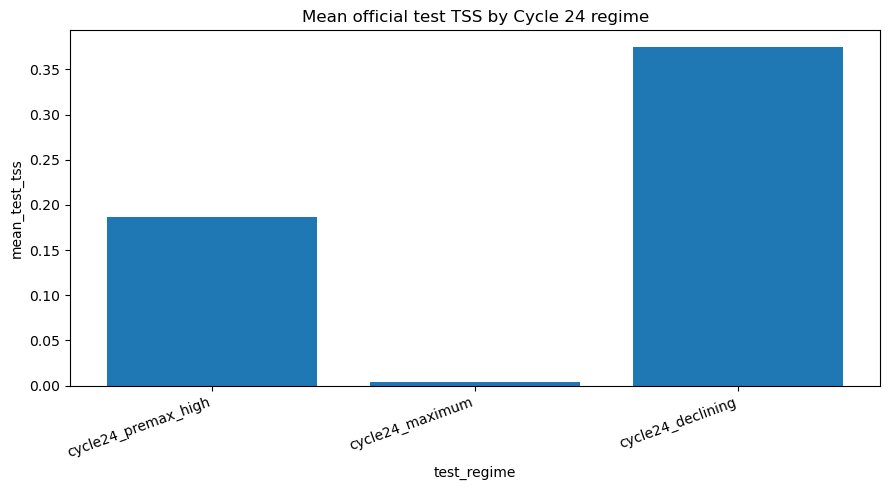

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_resnet18_cycle_phase_regime_mean_test_tss.png


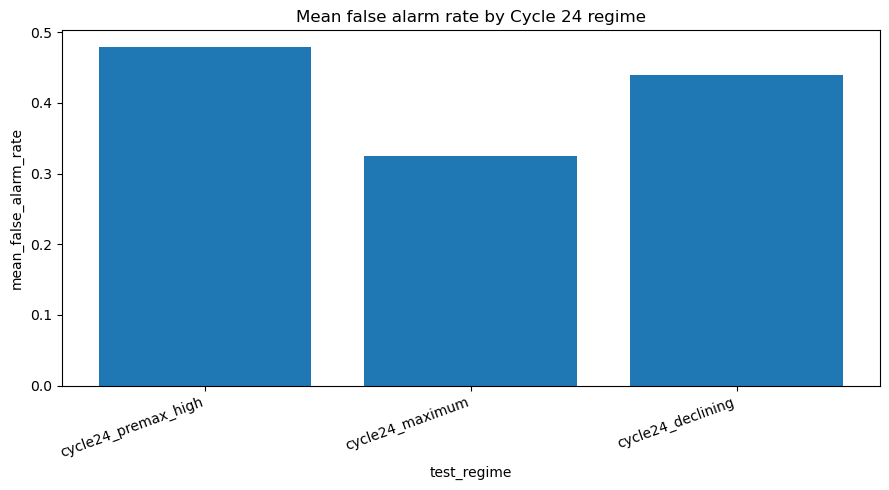

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_resnet18_cycle_phase_regime_false_alarm_rate.png


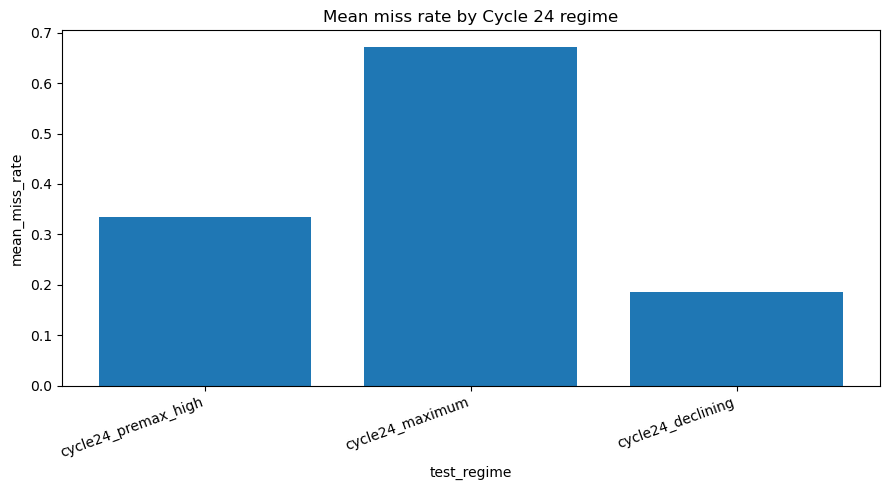

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_resnet18_cycle_phase_regime_miss_rate.png


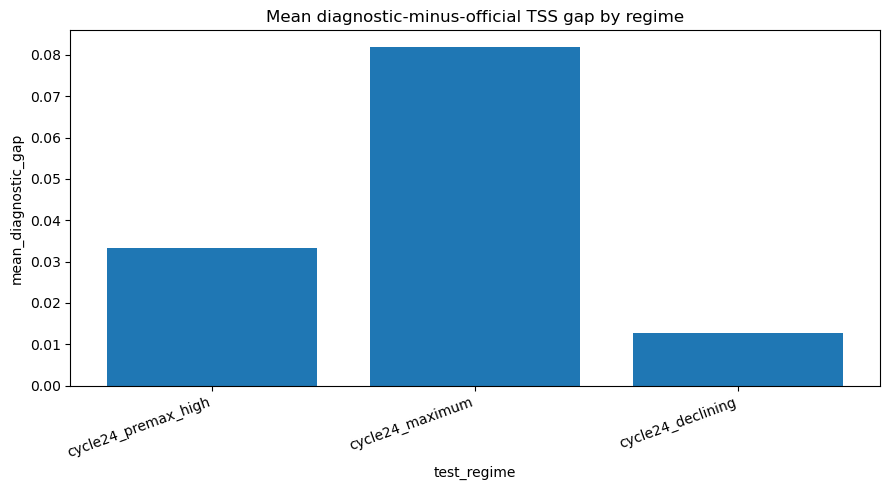

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_resnet18_cycle_phase_regime_threshold_transfer_gap.png


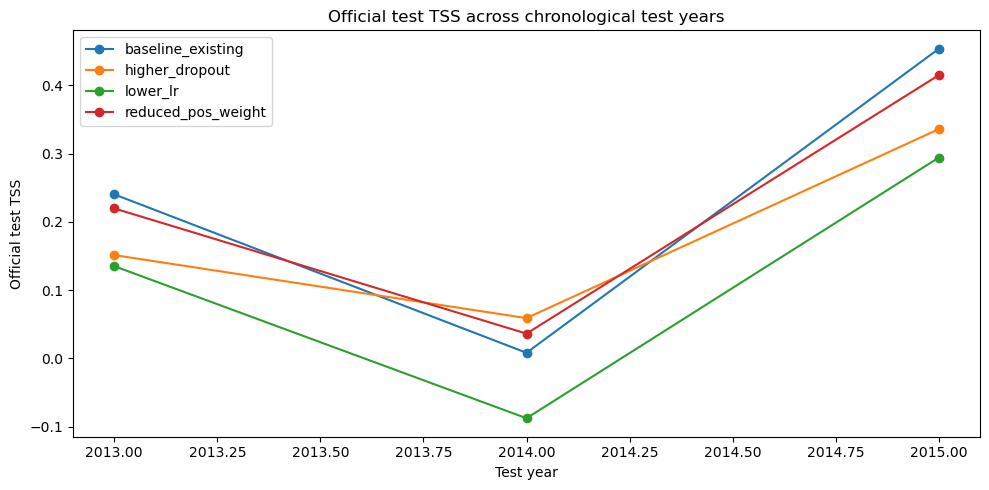

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/aia_resnet18_cycle_phase_regime_foldwise_tss_by_config.png


In [7]:
import matplotlib.pyplot as plt

def save_bar(df, x, y, title, filename, rotation=30):
    fig = plt.figure(figsize=(9, 5))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

plot1 = regime_hardness.sort_values("test_year")
save_bar(
    plot1, "test_regime", "mean_test_tss",
    "Mean official test TSS by Cycle 24 regime",
    "aia_resnet18_cycle_phase_regime_mean_test_tss.png",
    rotation=20
)

save_bar(
    plot1, "test_regime", "mean_false_alarm_rate",
    "Mean false alarm rate by Cycle 24 regime",
    "aia_resnet18_cycle_phase_regime_false_alarm_rate.png",
    rotation=20
)

save_bar(
    plot1, "test_regime", "mean_miss_rate",
    "Mean miss rate by Cycle 24 regime",
    "aia_resnet18_cycle_phase_regime_miss_rate.png",
    rotation=20
)

save_bar(
    threshold_regime.sort_values("test_year"), "test_regime", "mean_diagnostic_gap",
    "Mean diagnostic-minus-official TSS gap by regime",
    "aia_resnet18_cycle_phase_regime_threshold_transfer_gap.png",
    rotation=20
)

fig = plt.figure(figsize=(10, 5))
for cfg, sub in regime_results.sort_values("test_year").groupby("config_name"):
    plt.plot(sub["test_year"], sub["test_tss"], marker="o", label=cfg)
plt.title("Official test TSS across chronological test years")
plt.xlabel("Test year")
plt.ylabel("Official test TSS")
plt.legend()
plt.tight_layout()
path = FIG_DIR / "aia_resnet18_cycle_phase_regime_foldwise_tss_by_config.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", path)


## 7. Paper-ready interpretation and research log update

In [8]:
def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

hardest = regime_hardness.sort_values("mean_test_tss").iloc[0]
selected_mean = config_summary[config_summary["config_name"] == selected_config]
selected_text = ""
if len(selected_mean):
    s = selected_mean.iloc[0]
    selected_text = (
        f"`{selected_config}` was selected by mean validation TSS "
        f"({fmt(s.get('val_tss_mean'))} ± {fmt(s.get('val_tss_std'))}). "
        f"Its mean official test TSS was {fmt(s.get('test_tss_mean'))} ± {fmt(s.get('test_tss_std'))}."
    )
else:
    selected_text = f"`{selected_config}` was the validation-selected configuration."

baseline_mean = config_summary[config_summary["config_name"] == "baseline_existing"]
baseline_text = ""
if len(baseline_mean):
    b = baseline_mean.iloc[0]
    baseline_text = (
        f"The existing baseline retained mean official test TSS={fmt(b.get('test_tss_mean'))} "
        f"with high fold-to-fold variation (std={fmt(b.get('test_tss_std'))})."
    )

regime_text = f"""
## Research log update — Cycle/Regime Diagnostics for AIA ResNet18

**Timestamp:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

### Diagnostic purpose

Completed CPU-only cycle/regime diagnostics after the AIA ResNet18 physics-safe multifold and hyperparameter sensitivity experiments. This notebook did not train models; it analysed fold-level behaviour, threshold transfer, false-alarm/miss patterns, and regime labels for the chronological test years.

### Main finding

The hardest chronological regime remains **{hardest['test_regime']}** / **{hardest['fold_id']}**, with mean official test TSS={fmt(hardest['mean_test_tss'])}. This supports the conclusion that the weak fold is not fully explained by small hyperparameter choices.

### Validation-selected model

{selected_text}

{baseline_text}

### Scientific interpretation

The current AIA-only experiment is best interpreted as a **within-Solar-Cycle-24 chronological robustness test**, not a direct Cycle 24 versus Cycle 25 experiment. The performance variation across 2013, 2014, and 2015 indicates that image-only AIA snapshots can capture useful morphology/thermal-emission cues, but they are not sufficiently stable across solar-cycle phase/regime shifts.

The 2014 fold remains scientifically important because it represents the Cycle 24 maximum-regime diagnostic case in this experimental setup. The persistence of weak official test TSS around this fold strengthens the argument for multimodal forecasting rather than further image-only tuning.

### Next step

Proceed to the AIA+SHARP fusion stage:

1. AIA branch for EUV morphology and coronal emission structure.
2. SHARP temporal branch for magnetic free-energy, shear, current, flux, and active-region evolution.
3. Chronological fold evaluation with validation-selected thresholds.
4. Regime-aware reporting to show where multimodal fusion improves or fails.

### Files generated

- `results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_config_fold_summary.csv`
- `results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_fold_regime_hardness.csv`
- `results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_selected_config_profile.csv`
- `results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_threshold_transfer_by_regime.csv`
- `results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_research_log_update.md`
- `results/figures/aia_resnet18_cycle_phase_regime_*.png`
""".strip()

out_log = METRICS_DIR / "aia_resnet18_cycle_phase_regime_diagnostics_research_log_update.md"
out_log.write_text(regime_text, encoding="utf-8")

print(regime_text)
print("\nSaved:", out_log)


## Research log update — Cycle/Regime Diagnostics for AIA ResNet18

**Timestamp:** 2026-08-03 15:51:49

### Diagnostic purpose

Completed CPU-only cycle/regime diagnostics after the AIA ResNet18 physics-safe multifold and hyperparameter sensitivity experiments. This notebook did not train models; it analysed fold-level behaviour, threshold transfer, false-alarm/miss patterns, and regime labels for the chronological test years.

### Main finding

The hardest chronological regime remains **cycle24_maximum** / **test_2014**, with mean official test TSS=0.0038. This supports the conclusion that the weak fold is not fully explained by small hyperparameter choices.

### Validation-selected model

`higher_dropout` was selected by mean validation TSS (0.2403 ± 0.0219). Its mean official test TSS was 0.1819 ± 0.1409.

The existing baseline retained mean official test TSS=0.2339 with high fold-to-fold variation (std=0.2227).

### Scientific interpretation

The current AIA-only experiment is best

## 8. Final inventory

In [9]:
print("Generated metrics:")
for p in sorted(METRICS_DIR.glob("aia_resnet18_cycle_phase_regime_diagnostics_*")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("aia_resnet18_cycle_phase_regime_*.png")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nFinished:", datetime.now().isoformat(timespec="seconds"))


Generated metrics:
 - results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_config_fold_summary.csv (2.6 KiB)
 - results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_fold_regime_hardness.csv (0.7 KiB)
 - results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_research_log_update.md (2.5 KiB)
 - results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_selected_config_profile.csv (0.9 KiB)
 - results/metrics/aia_resnet18_cycle_phase_regime_diagnostics_threshold_transfer_by_regime.csv (0.5 KiB)

Generated figures:
 - results/figures/aia_resnet18_cycle_phase_regime_false_alarm_rate.png (63.6 KiB)
 - results/figures/aia_resnet18_cycle_phase_regime_foldwise_tss_by_config.png (138.9 KiB)
 - results/figures/aia_resnet18_cycle_phase_regime_mean_test_tss.png (67.3 KiB)
 - results/figures/aia_resnet18_cycle_phase_regime_miss_rate.png (62.8 KiB)
 - results/figures/aia_resnet18_cycle_phase_regime_threshold_transfer_gap.png (73.3 KiB)

Finished: 2026-08-03T15:51:49
